# 0 Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd

from matplotlib import pyplot as plt

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

from src.suporte import funcoes_suporte as fs

## 0.1 Funções Suporte

In [2]:
fs.jupyter_settings(altura = 16, largura = 8, fonte = 8)
fs.supressao_notacao(casa_decimal = 2)

# 0.2 Load Data

In [3]:
df_hp = fs.load_pickle("../data/interim/2.fe.pkl")
df_hp.sample(5)

,customer_id,faturamento,recencia_days,invoice_no
2612,16184,1155.54,64,7
888,17888,525.78,18,10
3826,16243,409.10,33,2
1089,16655,3794.52,17,6
1416,12414,562.41,217,3


# 1.0 Hyper

In [4]:
X = df_hp.drop(columns=["customer_id"])
X.head()

,faturamento,recencia_days,invoice_no
0,5288.63,302,35
1,3079.10,31,18
2,7187.34,2,18
3,948.25,95,5
4,635.10,330,6


In [7]:
clusters = [2,3,4,5,6]
kmeans = KMeans( init='random', n_init=10, max_iter=300, random_state=88)

## 1.1. Within-Cluster Sum of Square (WSS)

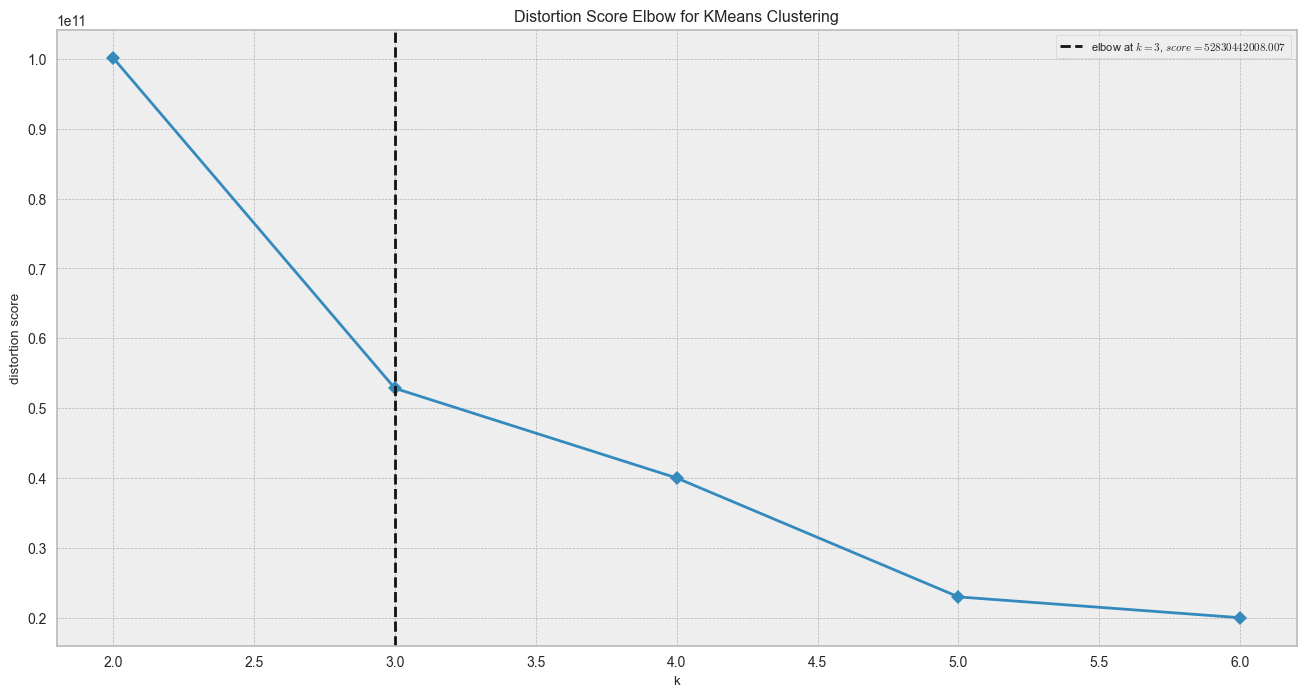

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [9]:
kmeans_wss = KElbowVisualizer(kmeans, k=clusters, timings=False, force_model=True)
kmeans_wss.fit(X)
kmeans_wss.show()

## 1.2. Silhouette Score (SS)

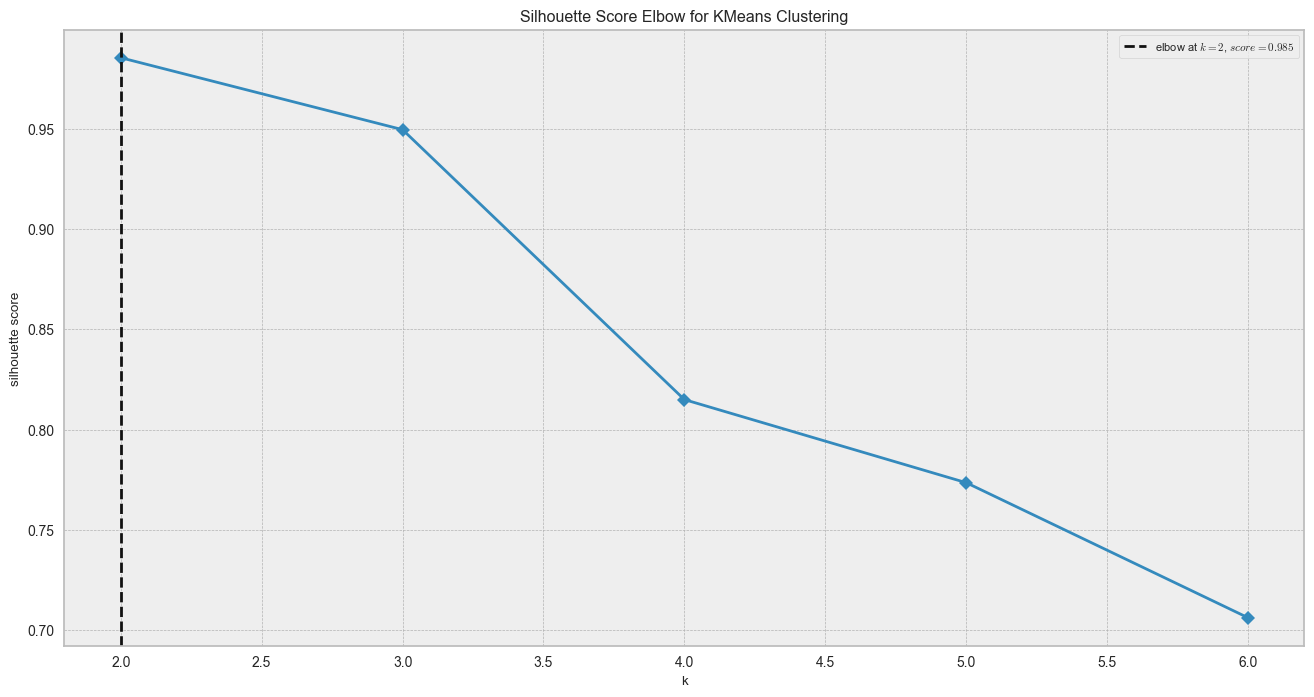

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [13]:
kmeans_ss = KElbowVisualizer( kmeans, k=clusters, metric='silhouette', timings=False, force_model=True)
kmeans_ss.fit(X)
kmeans_ss.show()

# 2. Definição de K

Conforme visto, foi definido para essa iteração K=3

# 3 Exportar dados utilizados

In [14]:
fs.save_pickle(X,'../data/interim/7.data-k-definition.pkl')